# Ian

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
from model_multi_real import MultiScaleCoupledHawkesReal

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 140

MAIN_NPZ = Path("/Users/sylvia/Desktop/JHU/dataset/readytoplot/lee_ian_by_cbg_2state_dr0.005_tr0.6_new_dr0.005_tr0.6.npz")
GRAPH_NPZ = Path("/Users/sylvia/Desktop/JHU/graph_ours_seed17.npz")
CKPT_PATH = Path("/Users/sylvia/Desktop/JHU/dataset/checkpoint/final_checkpoint_ian.pt")
DEVICE = "cpu"

EVENT_TYPES = ["sell", "repair"]
COASTAL_REFERENCE_POINTS = [
    (-82.274, 26.868),  # Cayo Costa / Captiva barrier islands
    (-82.069, 26.643),  # Sanibel Island
    (-81.950, 26.452),  # Estero Island / Fort Myers Beach
    (-81.820, 26.280),  # Bonita Beach
]


In [107]:
from math import radians, sin, cos, asin, sqrt

def haversine_km(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2.0) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2.0) ** 2
    c = 2 * asin(min(1.0, sqrt(a)))
    return 6371.0 * c


def estimate_distance_to_coast(lon, lat, reference_points=COASTAL_REFERENCE_POINTS):
    if reference_points is None or len(reference_points) == 0:
        return np.nan
    return float(min(haversine_km(lon, lat, lon2, lat2) for lon2, lat2 in reference_points))


def get_feature_names(meta):
    numeric_features = list(meta["numeric_features"])
    categorical_features = [
        "usecode",
        "zoning",
        "lbcs_activity",
        "lbcs_function",
        "lbcs_structure",
        "owntype",
        "fema_flood_zone",
        "ian_Occupancy",
        "ian_DamageLevel",
    ]
    return numeric_features + categorical_features


def load_graph_outputs(main_npz_path, graph_npz_path):
    main_npz = np.load(main_npz_path, allow_pickle=True)
    communities = main_npz["communities"]
    meta = main_npz["meta"].item()
    time_index = pd.to_datetime(main_npz["time_index"])

    graphs_npz = np.load(graph_npz_path, allow_pickle=True)
    graph_lookup = {}
    for entry in graphs_npz["graphs"]:
        gdict = entry if isinstance(entry, dict) else entry.item()
        idx = int(gdict["community_global_index"])
        graph_lookup[idx] = gdict
    return communities, meta, time_index, graph_lookup


def summarize_communities(communities, feature_names, meta=None):
    feature_idx = {name: i for i, name in enumerate(feature_names)}
    damage_mapping = (meta.get("cat_mappings") or {}).get("ian_DamageLevel") if meta else None
    damage_unknown = set()
    if damage_mapping:
        damage_unknown = {
            code for label, code in damage_mapping.items()
            if isinstance(label, str) and label.upper().startswith("UNK")
        }

    def safe_mean(arr):
        if arr is None or arr.size == 0:
            return np.nan
        return float(np.mean(arr))

    def safe_percentile(arr, q):
        if arr is None or arr.size == 0:
            return np.nan
        return float(np.percentile(arr, q))

    records = []
    for idx, comm in enumerate(communities):
        coords = np.asarray(comm["coords"], dtype=float)
        X = np.asarray(comm["X"], dtype=float)
        Y = np.asarray(comm["Y"], dtype=float)
        lon_c = float(coords[:, 0].mean())
        lat_c = float(coords[:, 1].mean())
        dist_gulf = estimate_distance_to_coast(lon_c, lat_c)

        def grab(name):
            col_idx = feature_idx.get(name)
            if col_idx is None:
                return None
            return X[:, col_idx]

        sell_events = float(Y[:, :, 0].sum()) if Y.shape[-1] >= 1 else 0.0
        repair_events = float(Y[:, :, 1].sum()) if Y.shape[-1] >= 2 else 0.0
        n_parcels = X.shape[0]

        damage_codes = grab("ian_DamageLevel")
        damage_mean = np.nan
        if damage_codes is not None:
            finite_mask = np.isfinite(damage_codes)
            if finite_mask.any():
                codes = damage_codes[finite_mask].astype(int)
                if damage_unknown:
                    codes = codes[~np.isin(codes, tuple(damage_unknown))]
                if codes.size:
                    damage_mean = float(np.mean(codes))

        records.append(
            {
                "community_index": idx,
                "cbg": comm["cbg"],
                "n_parcels": n_parcels,
                "centroid_lon": lon_c,
                "centroid_lat": lat_c,
                "distance_to_gulf_km": dist_gulf,
                "median_income": safe_mean(grab("median_household_income")),
                "population_density": safe_mean(grab("population_density")),
                "flood_depth_mean": safe_mean(grab("ian_FloodDepth")),
                "flood_depth_p90": safe_percentile(grab("ian_FloodDepth"), 90),
                "sell_events": sell_events,
                "repair_events": repair_events,
                "ian_DamageLevel": damage_mean,
            }
        )

    df = pd.DataFrame.from_records(records)
    df["events_total"] = df["sell_events"] + df["repair_events"]
    df["events_per_100_parcels"] = df["events_total"] / df["n_parcels"].clip(lower=1) * 100.0
    return df

def load_hdd_model_from_ckpt(ckpt_path: Path, npz_path: Path, device: str = "cpu"):
    """
    Load HDD model from checkpoint. Construct a dummy model with correct shapes,
    then load state_dict. Buffers like mu/sigma will be overwritten by state_dict.
    """
    data = np.load(npz_path, allow_pickle=True)
    communities = list(data["communities"])
    meta = data["meta"].item()

    d_in = communities[0]["X"].shape[1]
    K = communities[0]["Y"].shape[2]

    dummy_mu = torch.zeros(d_in, dtype=torch.float32)
    dummy_sigma = torch.ones(d_in, dtype=torch.float32)

    model = MultiScaleCoupledHawkesReal(
        d_in=d_in,
        K=K,
        mu=dummy_mu.to(device),
        sigma=dummy_sigma.to(device),
        d_hid=128,
    ).to(device)

    ckpt = torch.load(ckpt_path, map_location=device)
    if isinstance(ckpt, dict) and ("model_state" in ckpt):
        state = ckpt["model_state"]
    elif isinstance(ckpt, dict) and ("state_dict" in ckpt):
        state = ckpt["state_dict"]
    else:
        state = ckpt

    model.load_state_dict(state, strict=False)
    model.eval()
    return model, meta


def compute_neural_intensity_model(comm_idx, comm, model, gamma_vec, event_type, T_train, device="cpu"):
    """
    Compute neighbor/self ratio using model's step_intensity decomposition.
    self := baseline + self_raw (diag + cross_self), nei := cross_nei * alpha_nei.
    """
    X = torch.from_numpy(comm["X"]).float().to(device)
    coords = torch.from_numpy(comm["coords"]).float().to(device)
    Y = torch.from_numpy(comm["Y"]).float().to(device)

    T, N, K = Y.shape
    T_use = min(T, int(T_train))

    H_g, w_self_node, A_list, baseline_node = model.build_structures(X, coords)
    w_self_node = torch.clamp(w_self_node, min=0.0)

    R_self = torch.zeros(N, K, dtype=torch.float32, device=device)

    self_sum = 0.0
    nei_sum = 0.0

    for t in range(T_use):
        if t > 0:
            R_self = gamma_vec.view(1, K) * R_self + Y[t - 1]

        R_nei_cols = []
        for k in range(K):
            Rk = R_self[:, k:k+1]
            R_nei_cols.append(A_list[k] @ Rk)
        R_nei = torch.cat(R_nei_cols, dim=1)

        baseline_k = model.b[event_type].view(1) + baseline_node[:, event_type]
        diag_term_k = w_self_node[:, event_type] * R_self[:, event_type]
        cross_self_k = (R_self @ model.W_self.T)[:, event_type]
        cross_nei_k = (R_nei @ model.W_nei.T)[:, event_type]
        cross_nei_k = cross_nei_k * model.alpha_nei[event_type].view(1)

        self_k = baseline_k + diag_term_k + cross_self_k

        self_sum += self_k.sum().item()
        nei_sum += cross_nei_k.sum().item()

    scale = max(N, 1)
    self_mean = self_sum / scale
    nei_mean = nei_sum / scale
    self_pos = float(F.softplus(torch.tensor(self_mean)).item())
    nei_pos = float(F.softplus(torch.tensor(nei_mean)).item())
    ratio = nei_pos / (self_pos + 1e-9)

    return {
        "community_index": comm_idx,
        "nei_self_ratio": ratio,
        "self_component": self_mean,
        "neighbor_component": nei_mean,
    }

In [108]:
import torch.nn.functional as F

communities, meta, time_index, graph_lookup = load_graph_outputs(MAIN_NPZ, GRAPH_NPZ)
model, meta = load_hdd_model_from_ckpt(CKPT_PATH, MAIN_NPZ, device=DEVICE)
feature_names = get_feature_names(meta)
T_train = int(meta.get("T_train", communities[0]["Y"].shape[0]))
K = communities[0]["Y"].shape[-1]
event_type = 0  # 0=sell, 1=repair

gamma_default = np.asarray(meta.get("gamma_k", [0.9]), dtype=float)
if gamma_default.size == 0:
    gamma_default = np.full((K,), 0.9, dtype=float)
if gamma_default.size < K:
    pad_val = gamma_default[-1] if gamma_default.size > 0 else 0.0
    gamma_default = np.pad(gamma_default, (0, K - gamma_default.size), constant_values=pad_val)
else:
    gamma_default = gamma_default[:K]

community_summary = summarize_communities(communities, feature_names, meta)
community_summary["has_graph"] = community_summary["community_index"].isin(graph_lookup)

intensity_records = []
for comm_idx, graph in graph_lookup.items():
    comm = communities[comm_idx]
    intensity_records.append(
        compute_neural_intensity_model(comm_idx, comm, model, torch.tensor(gamma_default, dtype=torch.float32, device=DEVICE), event_type, T_train, device=DEVICE)
    )
intensity_df = pd.DataFrame(intensity_records)

community_summary = community_summary.merge(intensity_df, on="community_index", how="inner")
community_summary = community_summary[(community_summary["sell_events"] > 0) & (community_summary["repair_events"] > 0)]
top_outliers = community_summary.nlargest(2, "nei_self_ratio").index
community_summary = community_summary.drop(index=top_outliers)
community_summary = community_summary.sort_values("distance_to_gulf_km").reset_index(drop=True)
community_summary[["community_index", "cbg", "n_parcels", "nei_self_ratio", "events_per_100_parcels"]].head()

,community_index,cbg,n_parcels,nei_self_ratio,events_per_100_parcels
0,546,120710019111,397,2.596377e-06,7.052897
1,139,120710019131,826,2.226552e-06,32.324455
2,523,120710019163,407,7.846495e-07,9.582310
3,460,120710019121,228,1.954395e-05,60.964912
4,452,120710019161,606,5.630341e-06,53.135314


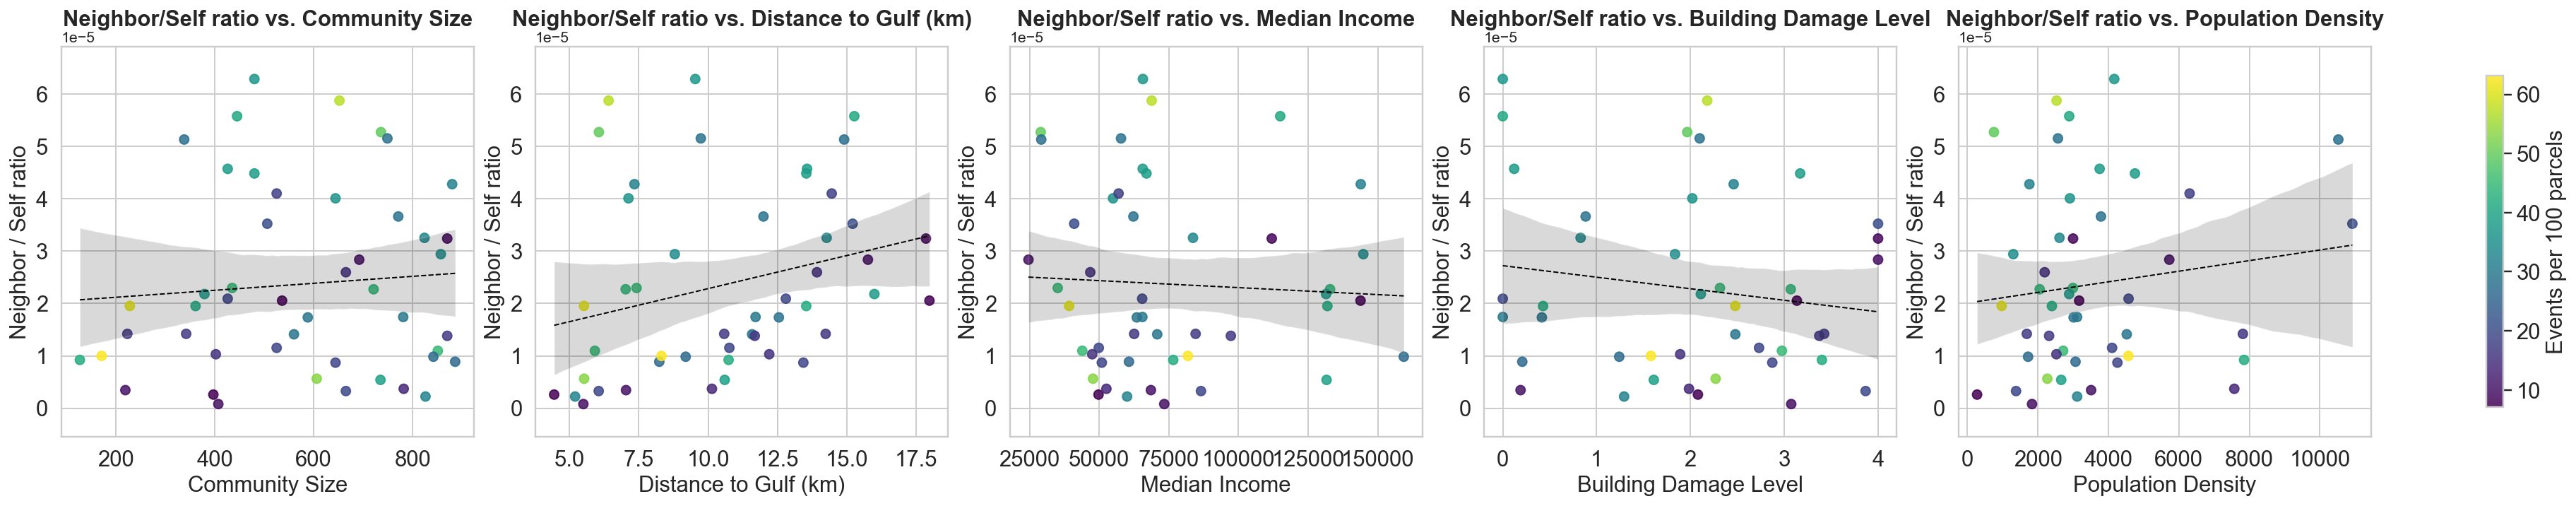

In [110]:
plots = [
    ("n_parcels", "Community Size"),
    ("distance_to_gulf_km", "Distance to Gulf (km)"),
    ("median_income", "Median Income"),
    ("ian_DamageLevel", "Building Damage Level"),
    ("population_density", "Population Density"),
]

plot_df = community_summary.dropna(subset=["nei_self_ratio"])
fig, axes = plt.subplots(1, len(plots), figsize=(26, 5), constrained_layout=True)
scatter = None
for ax, (col, label) in zip(axes, plots):
    if col not in plot_df.columns:
        ax.axis("off")
        ax.set_title(f"Missing: {label}")
        continue
    valid = plot_df.dropna(subset=[col, "nei_self_ratio"])
    valid = valid[np.isfinite(valid[col]) & np.isfinite(valid["nei_self_ratio"])]
    if col == "ian_DamageLevel":
        valid = valid[valid[col] >= 0]
    if valid.empty:
        ax.axis("off")
        ax.set_title(f"No data: {label}")
        continue
    scatter = ax.scatter(
        valid[col],
        valid["nei_self_ratio"],
        c=valid["events_per_100_parcels"],
        cmap="viridis",
        alpha=0.85,
        s=45,
    )
    sns.regplot(
        data=valid,
        x=col,
        y="nei_self_ratio",
        scatter=False,
        ax=ax,
        color="black",
        line_kws={"linestyle": "--", "linewidth": 1},
    )
    ax.set_title(f"Neighbor/Self ratio vs. {label}", fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel(label, fontsize=16)
    ax.set_ylabel("Neighbor / Self ratio", fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ratio_vals = valid["nei_self_ratio"].to_numpy()
    ratio_min = float(np.nanmin(ratio_vals)) if ratio_vals.size else 0.0
    ratio_max = float(np.nanmax(ratio_vals)) if ratio_vals.size else 0.0
    if np.isfinite(ratio_min) and np.isfinite(ratio_max) and ratio_min != ratio_max:
        pad = (ratio_max - ratio_min) * 0.1
        ax.set_ylim(ratio_min - pad, ratio_max + pad)
    else:
        ax.set_ylim(ratio_min * 0.9, ratio_max * 1.1 + 1e-8)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

if scatter is not None:
    cbar = fig.colorbar(scatter, ax=axes, shrink=0.85)
    cbar.set_label("Events per 100 parcels", fontsize=16)
    cbar.ax.tick_params(labelsize=16)
plt.show()
